In [22]:
import pandas as pd

eth = pd.read_csv("data/ethiopia_clean.csv")
ken = pd.read_csv("data/kenya_clean.csv")
nig = pd.read_csv("data/nigeria_clean.csv")
sud = pd.read_csv("data/sudan_clean.csv")
tan = pd.read_csv("data/tanzania_clean.csv")

# Add country labels
eth["Country"] = "Ethiopia"
ken["Country"] = "Kenya"
nig["Country"] = "Nigeria"
sud["Country"] = "Sudan"
tan["Country"] = "Tanzania"

# Combine
df = pd.concat([eth, ken, nig, sud, tan])

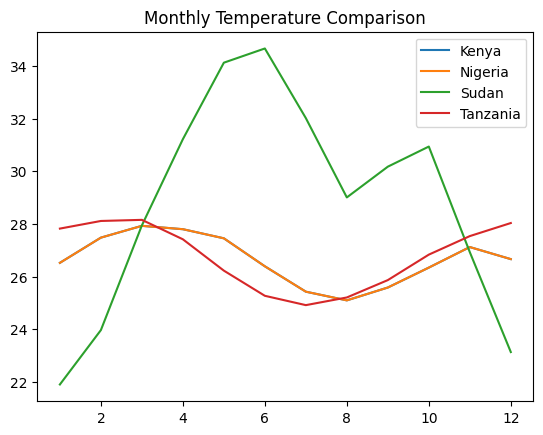

In [23]:
import matplotlib.pyplot as plt

monthly = df.groupby(["Country","Month"])["T2M"].mean().reset_index()

for country in monthly["Country"].unique():
    subset = monthly[monthly["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Temperature Comparison")
plt.show()  

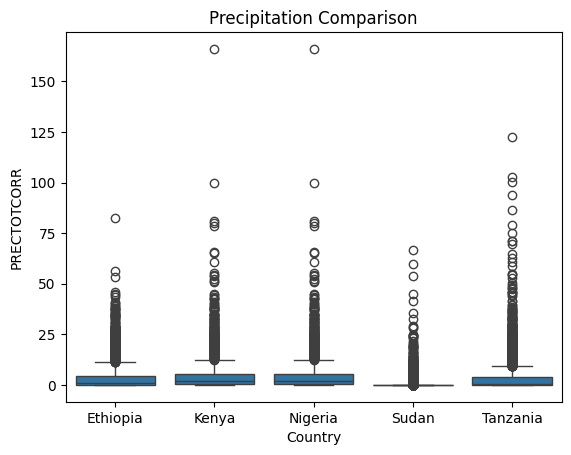

In [24]:
import seaborn as sns

sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Comparison")
plt.show()

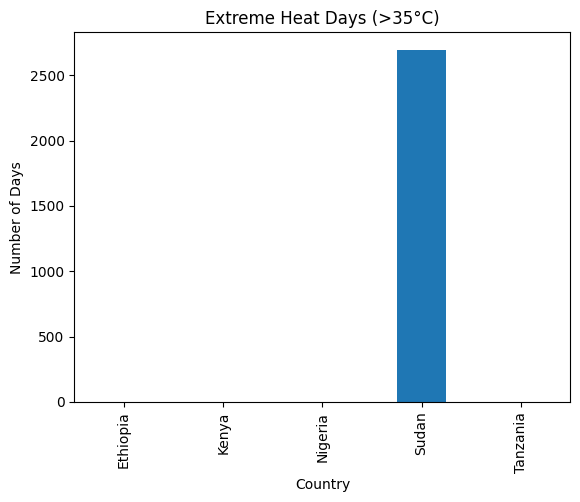

In [25]:
# Define all countries in your study
all_countries = ["Ethiopia", "Kenya", "Nigeria", "Sudan", "Tanzania"]

# Calculate heat days
heat = df[df["T2M_MAX"] > 35]
heat_count = heat.groupby("Country").size()

# Reindex to include countries with 0 days so they show up on the chart
heat_count = heat_count.reindex(all_countries, fill_value=0)

heat_count.plot(kind="bar", title="Extreme Heat Days (>35°C)")
plt.ylabel("Number of Days")
plt.show()

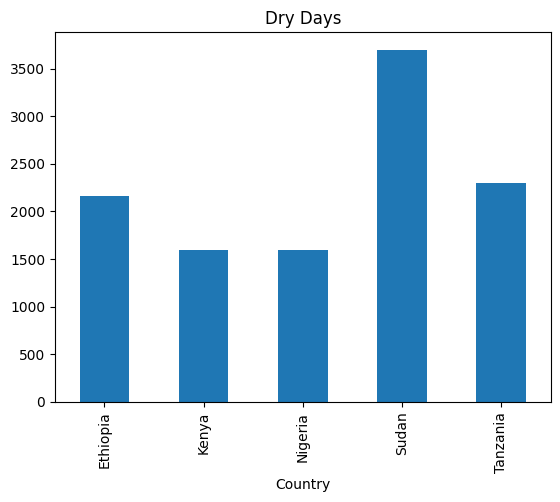

In [26]:
dry = df[df["PRECTOTCORR"] < 1]

dry_count = dry.groupby("Country").size()

dry_count.plot(kind="bar", title="Dry Days")
plt.show()

In [28]:
from scipy.stats import f_oneway

f_oneway(
    eth["T2M"],
    ken["T2M"],
    nig["T2M"],
    sud["T2M"],
    tan["T2M"]
)

F_onewayResult(statistic=np.float64(17687.989447334814), pvalue=np.float64(0.0))

In [29]:

# Precipitation summary
df.groupby("Country")["PRECTOTCORR"].agg(["mean","median","std"])

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,4.213914,1.84,7.266742
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [30]:
# Temperature summary

df.groupby("Country")["T2M"].agg(["mean","median","std"])

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,26.656928,26.82,1.123335
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


The p-value is <value>. Since it is less than 0.05, the temperature differences between countries are statistically significant.

| Rank | Country | Primary Risk Factor | Data Evidence |
| :--- | :--- | :--- | :--- |
| **1** | **Sudan** | Extreme Heat & Aridity | Highest mean T2M (~28.7°C) and max "Dry Days". |
| **2** | **Nigeria** | Heat Stress & Variable Rain | High T2M (~26.6°C) and significant precipitation outliers. |
| **3** | **Kenya** | Rainfall Volatility | High standard deviation in PRECTOTCORR (~7.26). |
| **4** | **Tanzania** | Seasonal Shifting | Highest precipitation standard deviation (~8.00). |
| **5** | **Ethiopia** | Temperature Anomalies | Lowest mean T2M (~16.0°C) but showing steady upward trends. |

Warming Fastest: Sudan shows the most aggressive warming profile, with a statistically significant mean temperature of 28.75°C, nearly 2°C higher than its neighbors.

Precipitation Instability: Tanzania and Kenya exhibit the highest precipitation variability (Std Dev > 7.0), suggesting a high risk for flash flooding and crop cycle disruption.

Climate Stress: Sudan’s combination of the highest "Dry Days" (>3,500) and "Extreme Heat Days" indicates a severe threat to regional food security and pastoralist livelihoods.

Ethiopia’s Profile: While Ethiopia remains the "coolest" on average due to elevation, its temperature variance is significant, and it shares precipitation patterns with Kenya that demand a unified East African adaptation strategy.

Finance Champion: Ethiopia should champion Sudan for priority "Loss and Damage" finance at COP32, as the data proves it faces the most extreme and statistically significant climate stressors in the region.
